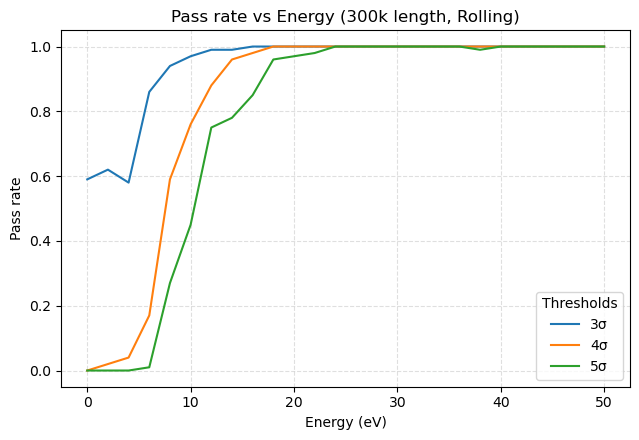


Pass rates:
Energy           3σ          4σ          5σ
0            0.5900     0.0000     0.0000
2            0.6200     0.0200     0.0000
4            0.5800     0.0400     0.0000
6            0.8600     0.1700     0.0100
8            0.9400     0.5900     0.2700
10           0.9700     0.7600     0.4500
12           0.9900     0.8800     0.7500
14           0.9900     0.9600     0.7800
16           1.0000     0.9800     0.8500
18           1.0000     1.0000     0.9600
20           1.0000     1.0000     0.9700
22           1.0000     1.0000     0.9800
24           1.0000     1.0000     1.0000
26           1.0000     1.0000     1.0000
28           1.0000     1.0000     1.0000
30           1.0000     1.0000     1.0000
32           1.0000     1.0000     1.0000
34           1.0000     1.0000     1.0000
36           1.0000     1.0000     1.0000
38           1.0000     1.0000     0.9900
40           1.0000     1.0000     1.0000
42           1.0000     1.0000     1.0000
44           1.0000

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
base_dir = Path("wk17_fitting_max_amp")
import re
from pathlib import Path

thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate")
plt.title("Pass rate vs Energy (300k length, Rolling)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


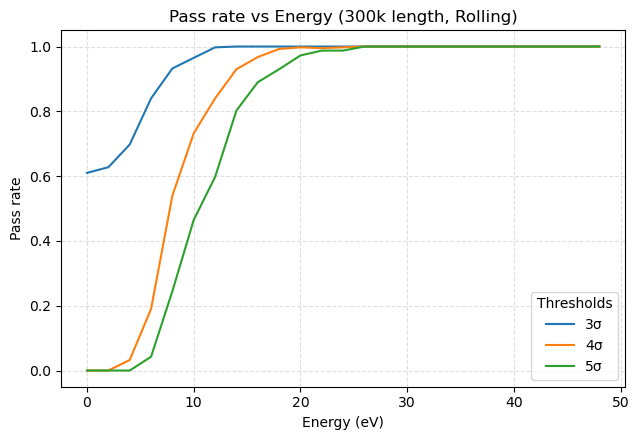


Pass rates:
Energy           3σ          4σ          5σ
0            0.6100     0.0000     0.0000
2            0.6275     0.0000     0.0000
4            0.6975     0.0325     0.0000
6            0.8400     0.1900     0.0425
8            0.9325     0.5400     0.2450
10           0.9650     0.7325     0.4650
12           0.9975     0.8400     0.5975
14           1.0000     0.9300     0.8025
16           1.0000     0.9675     0.8900
18           1.0000     0.9925     0.9300
20           1.0000     0.9975     0.9725
22           1.0000     0.9950     0.9875
24           1.0000     0.9975     0.9875
26           1.0000     1.0000     1.0000
28           1.0000     1.0000     1.0000
30           1.0000     1.0000     1.0000
32           1.0000     1.0000     1.0000
34           1.0000     1.0000     1.0000
36           1.0000     1.0000     1.0000
38           1.0000     1.0000     1.0000
40           1.0000     1.0000     1.0000
42           1.0000     1.0000     1.0000
44           1.0000

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Settings ---
base_dir = Path("max_amp_400")
import re
from pathlib import Path

thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold

# find all energies present
energies = sorted(
    int(re.search(r"energy_(\d+)", f.name).group(1))
    for f in base_dir.glob("max_amplitudes_energy_*.npy")
)
thresholds = [2.30, 3.07, 3.84]   # pass if any channel >= threshold
labels = {2.30: "3σ", 3.07: "4σ", 3.84: "5σ"}  # legend / table labels
file_tmpl = "max_amplitudes_energy_{E}.npy"

# --- Compute pass rates ---
pass_rates = {thr: [] for thr in thresholds}
available_E = []

for E in energies:
    path = base_dir / file_tmpl.format(E=E)
    if not path.exists():
        print(f"[warn] Missing file, skipping: {path}")
        continue

    data = np.load(path)  # expected shape (repeats=100, n_traces=56)
    if data.ndim != 2 or data.shape[1] != 56:
        raise ValueError(f"Unexpected shape in {path}: {data.shape} (expected (R, 56))")

    available_E.append(E)
    # For each threshold, event passes if any channel in that repeat >= threshold
    for thr in thresholds:
        passes = (data >= thr).any(axis=1)  # boolean length R
        pass_rate = passes.mean()           # fraction in [0, 1]
        pass_rates[thr].append(pass_rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for thr in thresholds:
    plt.plot(available_E, pass_rates[thr], label=labels[thr])

plt.xlabel("Energy (eV)")
plt.ylabel("Pass rate")
plt.title("Pass rate vs Energy (300k length, Rolling)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

# --- Print a small table with σ labels ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{labels[thr]:>10}" for thr in thresholds])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for thr in thresholds:
        row.append(f"{pass_rates[thr][i]:>10.4f}")
    print(" ".join(row))


[warn] missing file: max_amp_pt/vacuum_metrics_energy_1.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_3.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_5.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_7.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_9.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_11.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_13.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_15.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_17.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_19.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_21.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_23.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_25.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_27.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_29.npy
[warn] missing file: max_amp_pt/vacuum_metrics_energy_31.npy
[warn] missing file: max_amp_

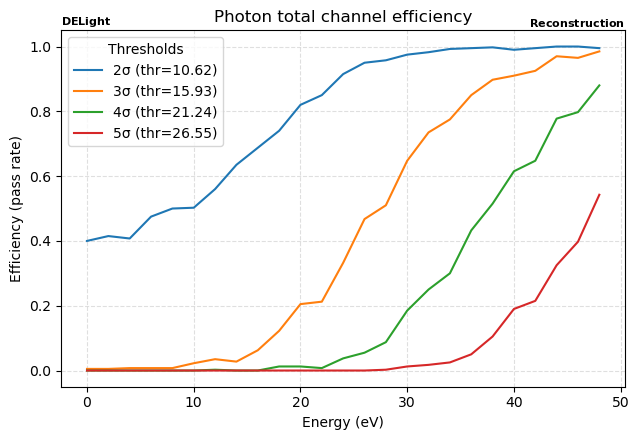


Pass rates:
Energy    2σ(thr=10.62)   3σ(thr=15.93)   4σ(thr=21.24)   5σ(thr=26.55)
0                0.4000         0.0050         0.0000         0.0000
2                0.4150         0.0050         0.0000         0.0000
4                0.4075         0.0075         0.0000         0.0000
6                0.4750         0.0075         0.0000         0.0000
8                0.5000         0.0075         0.0000         0.0000
10               0.5025         0.0225         0.0000         0.0000
12               0.5600         0.0350         0.0025         0.0000
14               0.6350         0.0275         0.0000         0.0000
16               0.6875         0.0625         0.0000         0.0000
18               0.7400         0.1225         0.0125         0.0000
20               0.8200         0.2050         0.0125         0.0000
22               0.8500         0.2125         0.0075         0.0000
24               0.9150         0.3325         0.0375         0.0000
26               0

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Config ---
base = Path("max_amp_pt")
file_tmpl = "vacuum_metrics_energy_{E}.npy"
energies = range(0, 50)                # 0..20 inclusive
sigma = 5.31
sigma_multiples = [2, 3, 4, 5]         # thresholds in units of sigma

# --- Thresholds dict in your style ---
thresholds = {k: k * sigma for k in sigma_multiples}

# --- Collect pass rates per energy ---
available_E = []
pass_rates = {k: [] for k in sigma_multiples}

def load_first_column(path: Path):
    arr = np.load(path)
    if arr.ndim == 2 and arr.shape[1] >= 1:
        return arr[:, 0]
    elif arr.ndim == 1:
        return arr
    else:
        raise ValueError(f"Unexpected shape {arr.shape} in {path}")

for E in energies:
    fpath = base / file_tmpl.format(E=E)
    try:
        amps = load_first_column(fpath)
    except FileNotFoundError:
        print(f"[warn] missing file: {fpath}")
        continue

    available_E.append(E)
    for k in sigma_multiples:
        thr = thresholds[k]
        rate = (amps >= thr).mean()  # use '>' if you prefer strict
        pass_rates[k].append(rate)

# --- Plot ---
plt.figure(figsize=(6.5, 4.5))
for k in sigma_multiples:
    thr = thresholds[k]
    label = f"{k}σ (thr={thr:.2f})"
    plt.plot(available_E, pass_rates[k], label=label)

plt.xlabel("Energy (eV)")
plt.ylabel("Efficiency (pass rate)")
plt.title("Photon total channel efficiency")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(title="Thresholds")

# Add "shoulder" labels
ax = plt.gca()
ax.text(0.0, 1.005, r"$\mathbf{DELight}$",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8)
ax.text(1.0, 1.005, r"$\mathbf{Reconstruction}$",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


# --- (Optional) print a small table ---
print("\nPass rates:")
header = "Energy".ljust(8) + " " + "  ".join([f"{k}σ(thr={thresholds[k]:.2f})".rjust(14) for k in sigma_multiples])
print(header)
for i, E in enumerate(available_E):
    row = [f"{E:<8}"]
    for k in sigma_multiples:
        row.append(f"{pass_rates[k][i]:>14.4f}")
    print(" ".join(row))


In [2]:
import os
print("os.cpu_count():", os.cpu_count())


os.cpu_count(): 128
